In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wti_env import WTIEnv
from dqn_agent import DQNAgent

In [4]:
# Load the merged dataset (includes weather + hurricane data)
df = pd.read_csv('wti_1_data_with_hurricanes.csv')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns:")
print(df.columns.tolist())

Dataset shape: (9586, 62)
Date range: 1986-01-02 to 2024-04-05

Columns:
['Date', 'spot_price', 'CL1', 'ret_CL1', 'alaska_temp', 'alaska_precip', 'bakken_temp', 'bakken_precip', 'western_canada_temp', 'western_canada_precip', 'midwest_corridor_temp', 'midwest_corridor_precip', 'ok_hub_temp', 'ok_hub_precip', 'permian_temp', 'permian_precip', 'rockies_temp', 'rockies_precip', 'texas_gulf_temp', 'texas_gulf_precip', 'bakken_temp_producing', 'bakken_precip_producing', 'canada_temp_producing', 'canada_precip_producing', 'eagle_temp_producing', 'eagle_precip_producing', 'central_kansas_temp_producing', 'central_kansas_precip_producing', 'n_alaska_temp_producing', 'n_alaska_precip_producing', 'nc_ok_temp_producing', 'nc_ok_precip_producing', 'ne_ok_temp_producing', 'ne_ok_precip_producing', 'nw_ok_temp_producing', 'nw_ok_precip_producing', 'permian_temp_producing', 'permian_precip_producing', 's_alaska_temp_producing', 's_alaska_precip_producing', 'saskatchewan_temp_producing', 'saskatchewan

In [5]:
# Define features and target
feature_cols = [c for c in df.columns if c not in ['Date', 'ret_CL1', 'spot_price', 'CL1']]
return_col = 'ret_CL1'

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature types:")
print(f"  - Pipeline weather (temp + precip): 16 features")
print(f"  - Producing region weather: 26 features")
print(f"  - Hurricane data: 16 features")

Number of features: 58

Feature types:
  - Pipeline weather (temp + precip): 16 features
  - Producing region weather: 26 features
  - Hurricane data: 16 features


In [6]:
# Check for NaN values
nan_counts = df.isna().sum()
print(f"NaN values in ret_CL1: {nan_counts['ret_CL1']}")
print("(These will be automatically dropped during model fitting)")

NaN values in ret_CL1: 3
(These will be automatically dropped during model fitting)


In [7]:
# Time-based split (80% train, 20% test)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print(f"Training data: {len(train_df)} samples ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Test data: {len(test_df)} samples ({test_df['Date'].min()} to {test_df['Date'].max()})")

Training data: 7668 samples (1986-01-02 to 2016-07-29)
Test data: 1918 samples (2016-08-01 to 2024-04-05)


In [8]:
# Create Gym environments for train and test

window_size = 20       # same as before (or whatever you used)
transaction_cost = 0.0005
normalize_features = True

train_env = WTIEnv(
    df=train_df,
    feature_cols=feature_cols,
    return_col=return_col,
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)

test_env = WTIEnv(
    df=test_df,
    feature_cols=feature_cols,
    return_col=return_col,
    window=window_size,
    cost=transaction_cost,
    normalize=normalize_features,
)




In [11]:
# Infer observation and action dimensions from the environment
sample_obs, _ = train_env.reset()
obs_shape = sample_obs.shape
n_actions = train_env.action_space.n

print("Observation shape:", obs_shape)
print("Number of actions:", n_actions)

# For a simple MLP, we'll flatten the observation
obs_dim = int(np.prod(obs_shape))

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Create DQN agent (hyperparameters can be tuned)
dqn = DQNAgent(
    obs_dim=obs_dim,
    n_actions=n_actions,
    gamma=0.95,          # discount factor, similar to POMDP gamma
    lr=1e-3,             # learning rate
    buffer_size=100_000,
    batch_size=64,
    target_update_freq=1000,   # how often to update target network (in steps)
    device=device,              # or "cuda" if available
)


Observation shape: (20, 58)
Number of actions: 3
Using device: cuda


In [12]:
# Train DQN agent on the training environment

n_episodes = 200
epsilon_start = 1.0
epsilon_end = 0.1
epsilon_decay_steps = 10_000  # total steps over which epsilon decays

training_rewards = dqn.train(
    env=train_env,
    n_episodes=n_episodes,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_steps=epsilon_decay_steps,
    max_steps_per_episode=None,   # or an int if you want to cap episode length
)

Episode 10/200, Reward: 17.3583, Avg(10): 20.9596, Epsilon: 0.100
Episode 20/200, Reward: 33.8450, Avg(10): 28.3759, Epsilon: 0.100
Episode 30/200, Reward: 39.4826, Avg(10): 38.0434, Epsilon: 0.100
Episode 40/200, Reward: 39.0584, Avg(10): 40.8263, Epsilon: 0.100
Episode 50/200, Reward: 39.9358, Avg(10): 42.1508, Epsilon: 0.100
Episode 60/200, Reward: 46.5590, Avg(10): 43.3519, Epsilon: 0.100
Episode 70/200, Reward: 46.5911, Avg(10): 47.4854, Epsilon: 0.100
Episode 80/200, Reward: 49.6011, Avg(10): 48.8456, Epsilon: 0.100
Episode 90/200, Reward: 51.0565, Avg(10): 50.4983, Epsilon: 0.100
Episode 100/200, Reward: 53.5741, Avg(10): 51.7814, Epsilon: 0.100
Episode 110/200, Reward: 52.8410, Avg(10): 51.5470, Epsilon: 0.100
Episode 120/200, Reward: 54.7605, Avg(10): 53.7131, Epsilon: 0.100
Episode 130/200, Reward: 56.7350, Avg(10): 55.3008, Epsilon: 0.100
Episode 140/200, Reward: 56.7090, Avg(10): 56.5695, Epsilon: 0.100
Episode 150/200, Reward: 55.9455, Avg(10): 56.5555, Epsilon: 0.100
Epis

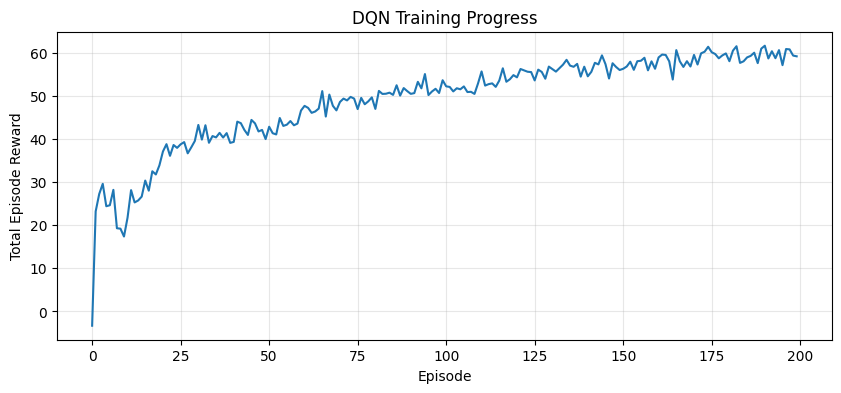

Final 10-episode average reward: 59.6720


In [13]:
# Plot training progress
plt.figure(figsize=(10, 4))
plt.plot(training_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Episode Reward')
plt.title('DQN Training Progress')
plt.grid(True, alpha=0.3)
plt.show()

# Rolling average
window = 10
rolling_avg = pd.Series(training_rewards).rolling(window).mean()
print(f"Final {window}-episode average reward: {rolling_avg.iloc[-1]:.4f}")


In [15]:
import torch
import os

os.makedirs("checkpoints", exist_ok=True)

save_path = "checkpoints/dqn_final.pt"

torch.save(
    {
        "model_state_dict": dqn.q_net.state_dict(),
        "target_model_state_dict": dqn.target_q_net.state_dict(),
        "optimizer_state_dict": dqn.optimizer.state_dict(),
        "total_steps": dqn.total_steps,
        "obs_dim": dqn.obs_dim,
        "n_actions": dqn.n_actions,
    },
    save_path
)

print("Saved model to:", save_path)

Saved model to: checkpoints/dqn_final.pt


In [16]:
from google.colab import files
files.download("checkpoints/dqn_final.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import torch

ckpt = torch.load(
    "checkpoints/dqn_final.pt",
    map_location=device,
    weights_only=False,   # <-- important
)

dqn_loaded = DQNAgent(
    obs_dim=ckpt.get("obs_dim", obs_dim),
    n_actions=ckpt.get("n_actions", n_actions),
    gamma=0.95,
    lr=1e-3,
    device=device,
)

dqn_loaded.q_net.load_state_dict(ckpt["model_state_dict"])
dqn_loaded.target_q_net.load_state_dict(ckpt["target_model_state_dict"])
dqn_loaded.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
dqn_loaded.total_steps = ckpt.get("total_steps", 0)

print("Loaded checkpoint successfully.")


Loaded checkpoint successfully.


In [19]:
# Evaluate DQN policy on the test environment (greedy, no exploration)

results = dqn_loaded.evaluate(test_env)

print("=== DQN Policy Results ===")
print(f"Total Reward: {results['total_reward']:.4f}")
print(f"Mean Daily Reward: {results['mean_reward']:.6f}")
print(f"Sharpe Ratio (annualized): {results['sharpe']:.4f}")


=== DQN Policy Results ===
Total Reward: 0.4493
Mean Daily Reward: 0.000237
Sharpe Ratio (annualized): 0.1276


In [20]:
test_returns = test_df.dropna(subset=[return_col])[return_col].values[:-1]

# Buy and Hold
buy_hold_reward = test_returns.sum()
buy_hold_sharpe = test_returns.mean() / (test_returns.std() + 1e-8) * np.sqrt(252)

# Sell and Hold (short)
sell_hold_reward = -test_returns.sum()

# Random
np.random.seed(42)
random_positions = np.random.choice([-1, 0, 1], size=len(test_returns))
random_reward = (random_positions * test_returns).sum()

print("\n=== Baseline Comparisons ===")
print(f"Buy & Hold:  Total={buy_hold_reward:.4f}, Sharpe={buy_hold_sharpe:.4f}")
print(f"Sell & Hold: Total={sell_hold_reward:.4f}")
print(f"Random:      Total={random_reward:.4f}")
print(f"DQN:         Total={results['total_reward']:.4f}, Sharpe={results['sharpe']:.4f}")



=== Baseline Comparisons ===
Buy & Hold:  Total=1.3725, Sharpe=0.3856
Sell & Hold: Total=-1.3725
Random:      Total=1.5728
DQN:         Total=0.4493, Sharpe=0.1276


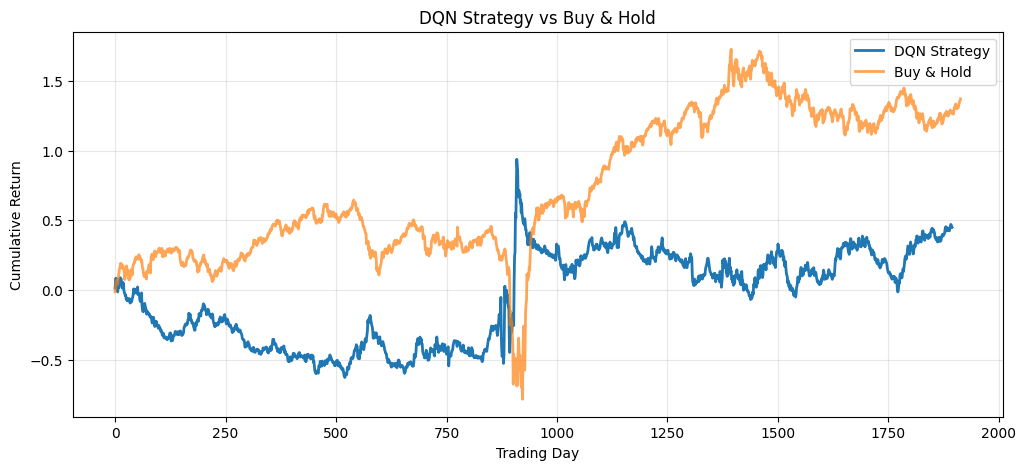

In [21]:
dqn_cumulative = np.cumsum(results['rewards'])
buyhold_cumulative = np.cumsum(test_returns)

plt.figure(figsize=(12, 5))
plt.plot(dqn_cumulative, label='DQN Strategy', linewidth=2)
plt.plot(buyhold_cumulative, label='Buy & Hold', linewidth=2, alpha=0.7)
plt.xlabel('Trading Day')
plt.ylabel('Cumulative Return')
plt.title('DQN Strategy vs Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


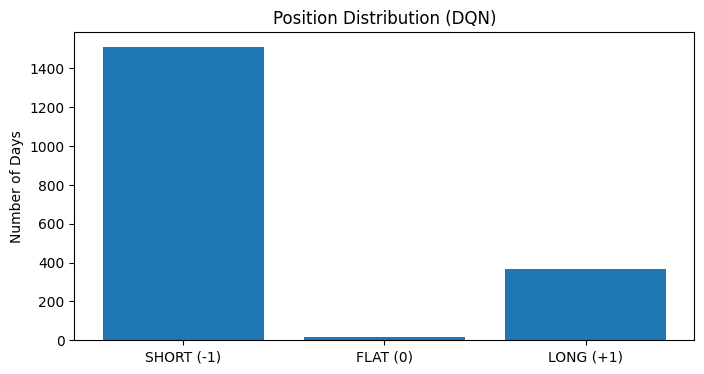

Position breakdown:
  SHORT: 1511 days (79.7%)
  FLAT:  18 days (0.9%)
  LONG:  366 days (19.3%)


In [22]:
positions = np.array(results['positions'])
position_counts = pd.Series(positions).value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(['SHORT (-1)', 'FLAT (0)', 'LONG (+1)'],
        [position_counts.get(-1, 0), position_counts.get(0, 0), position_counts.get(1, 0)])
plt.ylabel('Number of Days')
plt.title('Position Distribution (DQN)')
plt.show()

print(f"Position breakdown:")
print(f"  SHORT: {position_counts.get(-1, 0)} days ({100*position_counts.get(-1, 0)/len(positions):.1f}%)")
print(f"  FLAT:  {position_counts.get(0, 0)} days ({100*position_counts.get(0, 0)/len(positions):.1f}%)")
print(f"  LONG:  {position_counts.get(1, 0)} days ({100*position_counts.get(1, 0)/len(positions):.1f}%)")